#Air Quality data prediction of pollutants concentration

## Research Questions

1. How are meteorological variables such as temperature, relative humidity, and absolute humidity related to pollutant concentrations?

2. Which pollutants exhibit the strongest correlations with each other and what common emission sources may explain these relationships?

3. Can machine learning models such as XGBoost, LSTM, and GRU accurately predict NOx concentrations using environmental and sensor variables?

4. Which variables contribute most strongly to pollutant prediction according to feature importance analysis?

5. How do seasonal variations influence pollutant concentrations and air quality patterns?

Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load and store data into dataframe

## Data Description

The Air Quality dataset contains hourly measurements collected from an urban air-quality monitoring station. The dataset includes atmospheric pollutant concentrations, sensor responses, and meteorological variables that can be used to study air pollution dynamics and build predictive machine learning models.

### Pollutant Variables

| Variable | Description |
|-----------|-------------|
| CO_GT | Carbon Monoxide concentration |
| NMHC_GT | Non-Methane Hydrocarbons concentration |
| C6H6_GT | Benzene concentration |
| NOx_GT | Nitrogen Oxides concentration |
| NO2_GT | Nitrogen Dioxide concentration |

### Sensor Measurements

| Variable | Description |
|-----------|-------------|
| PT08_S1_CO | Sensor response for Carbon Monoxide |
| PT08_S2_NMHC | Sensor response for Non-Methane Hydrocarbons |
| PT08_S3_NOx | Sensor response for Nitrogen Oxides |
| PT08_S4_NO2 | Sensor response for Nitrogen Dioxide |
| PT08_S5_O3 | Sensor response related to Ozone |

### Meteorological Variables

| Variable | Description |
|-----------|-------------|
| T | Temperature (°C) |
| RH | Relative Humidity (%) |
| AH | Absolute Humidity |

### Study Objective

The objective of this analysis is to investigate relationships between environmental variables and atmospheric pollutants, identify key factors influencing air quality, and develop machine learning models capable of predicting pollutant concentrations.

### Importance of the Dataset

Air pollution is a major environmental and public health concern. Elevated concentrations of pollutants such as NOx, NO₂, Carbon Monoxide, and Benzene are associated with traffic emissions, industrial activities, and fuel combustion. Understanding their relationship with meteorological conditions helps improve air-quality forecasting and supports environmental decision-making.

In [2]:
ac_df = pd.read_excel('/content/sample_data/AirQualityUCI.xlsx')

In [3]:
ac_df.head(25)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.600,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.300,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.900,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.000,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.150,59.575001,0.788794
5,2004-03-10,23:00:00,1.2,1197.00,38,4.741012,750.25,89.0,1336.50,96.0,1393.00,949.25,11.175,59.175000,0.784772
6,2004-03-11,00:00:00,1.2,1185.00,31,3.624399,689.50,62.0,1461.75,77.0,1332.75,732.50,11.325,56.775000,0.760312
7,2004-03-11,01:00:00,1.0,1136.25,31,3.326677,672.00,62.0,1453.25,76.0,1332.75,729.50,10.675,60.000000,0.770238
8,2004-03-11,02:00:00,0.9,1094.00,24,2.339416,608.50,45.0,1579.00,60.0,1276.00,619.50,10.650,59.674999,0.764819
9,2004-03-11,03:00:00,0.6,1009.75,19,1.696658,560.75,-200.0,1705.00,-200.0,1234.75,501.25,10.250,60.200001,0.751657


Data Cleaning and pre-processing

In [4]:
ac_df = ac_df.replace(-200, 0)
ac_df = ac_df.replace(-200.0,0.0)
ac_df = ac_df.replace(-200.00,0.00)

In [15]:
print(ac_df['time'].dtype)

object


In [16]:
ac_df['time'] = ac_df['time'].astype(str)

In [17]:
print(ac_df['time'].dtype)

object


In [13]:
ac_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          9357 non-null   datetime64[ns]
 1   time          9357 non-null   object        
 2   co_gt         9357 non-null   float64       
 3   pt08_s1_co    9357 non-null   float64       
 4   nmhc_gt       9357 non-null   int64         
 5   c6h6_gt       9357 non-null   float64       
 6   pt08_s2_nmhc  9357 non-null   float64       
 7   nox_gt        9357 non-null   float64       
 8   pt08_s3_nox   9357 non-null   float64       
 9   no2_gt        9357 non-null   float64       
 10  pt08_s4_no2   9357 non-null   float64       
 11  pt08_s5_o3    9357 non-null   float64       
 12  t             9357 non-null   float64       
 13  rh            9357 non-null   float64       
 14  ah            9357 non-null   float64       
dtypes: datetime64[ns](1), float64(12), int

In [22]:
print(ac_df['date'])

0      2004-03-10
1      2004-03-10
2      2004-03-10
3      2004-03-10
4      2004-03-10
          ...    
9352   2005-04-04
9353   2005-04-04
9354   2005-04-04
9355   2005-04-04
9356   2005-04-04
Name: date, Length: 9357, dtype: datetime64[ns]


In [18]:
type(ac_df['time'].iloc[0])

str

In [20]:
print(ac_df['time'])

0       18:00:00
1       19:00:00
2       20:00:00
3       21:00:00
4       22:00:00
          ...   
9352    10:00:00
9353    11:00:00
9354    12:00:00
9355    13:00:00
9356    14:00:00
Name: time, Length: 9357, dtype: object


In [6]:
rename_map = {
    'C6H6(GT)': 'c6h6_gt',
    'CO(GT)': 'co_gt',
    'NOx(GT)': 'nox_gt',
    'NO2(GT)': 'no2_gt',
    'PT08.S1(CO)': 'pt08_s1_co',
    'PT08.S2(NMHC)': 'pt08_s2_nmhc',
    'PT08.S3(NOx)': 'pt08_s3_nox',
    'PT08.S4(NO2)': 'pt08_s4_no2',
    'PT08.S5(O3)': 'pt08_s5_o3',
    'T': 't',
    'RH': 'rh',
    'AH': 'ah',
    'Date': 'date',
    'Time': 'time',
    'NMHC(GT)': 'nmhc_gt'
}
ac_df = ac_df.rename(columns=rename_map)


Data Vizualisations of relations between different pollutants

/tmp/ipykernel_4635/498455281.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ac_df['hour'] = pd.to_datetime(


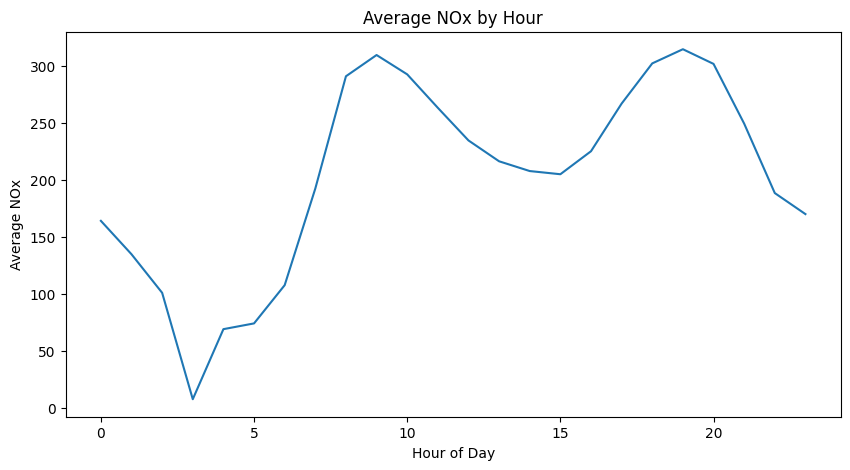

In [23]:
ac_df['hour'] = pd.to_datetime(
    ac_df['time']
).dt.hour

hourly_avg = (
    ac_df.groupby('hour')['nox_gt']
    .mean()
)

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index,
         hourly_avg.values)

plt.xlabel('Hour of Day')
plt.ylabel('Average NOx')
plt.title('Average NOx by Hour')
plt.show()

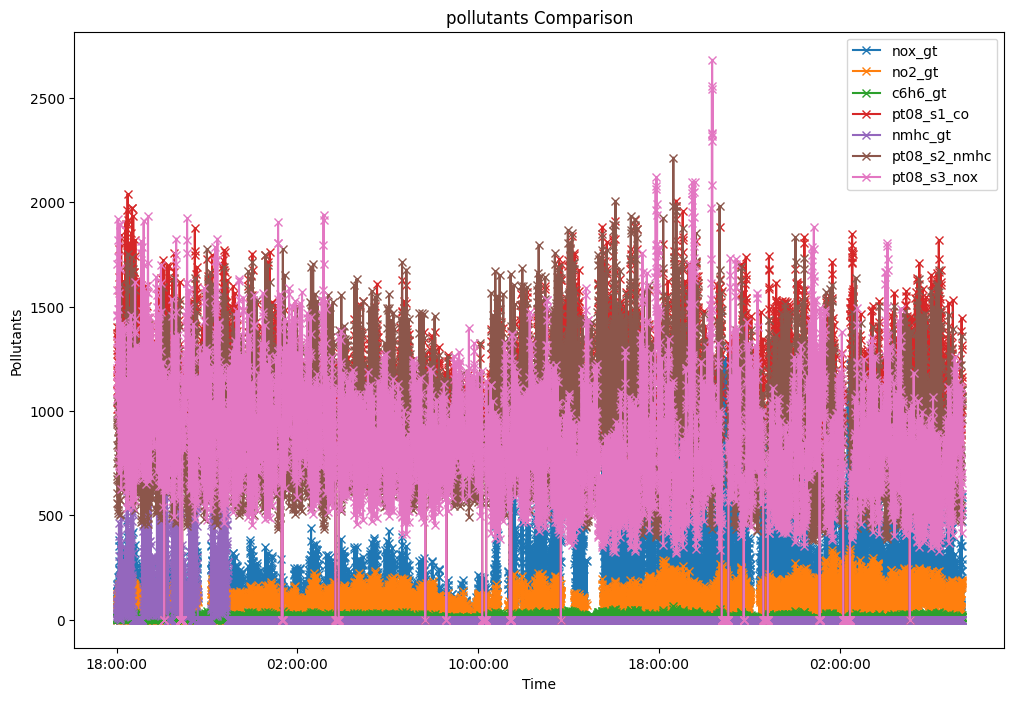

In [24]:
ac_df.plot(x='time', y=['nox_gt','no2_gt', 'c6h6_gt',
                        'pt08_s1_co', 'nmhc_gt',
                        'pt08_s2_nmhc', 'pt08_s3_nox'], marker='x', figsize=(12, 8))
plt.xlabel('Time')
plt.ylabel('Pollutants')
plt.title('pollutants Comparison')
plt.show()

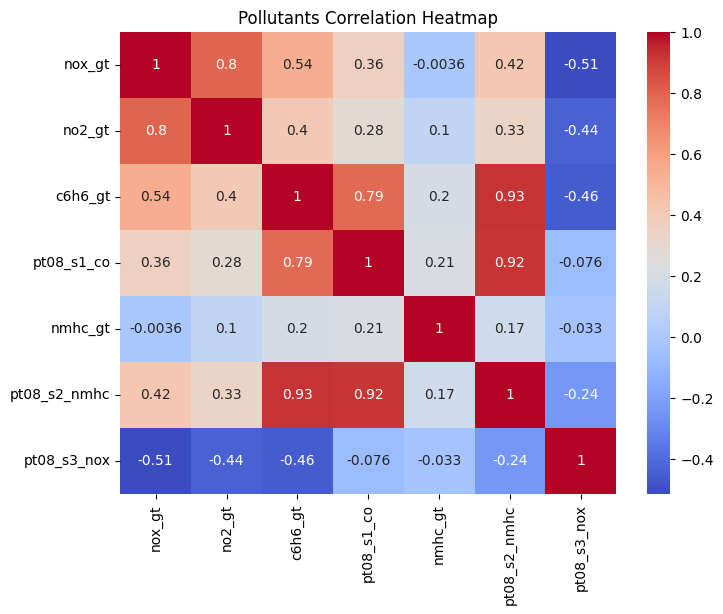

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['nox_gt','no2_gt','c6h6_gt',
        'pt08_s1_co','nmhc_gt',
        'pt08_s2_nmhc','pt08_s3_nox']

plt.figure(figsize=(8,6))
sns.heatmap(ac_df[cols].corr(),
            annot=True,
            cmap='coolwarm')
plt.title('Pollutants Correlation Heatmap')
plt.show()


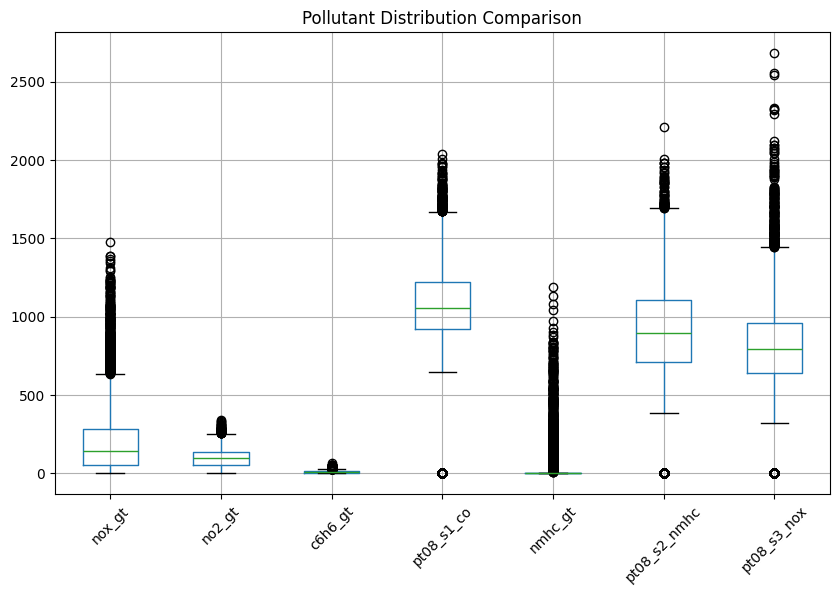

In [ ]:
cols = ['nox_gt','no2_gt','c6h6_gt',
        'pt08_s1_co','nmhc_gt',
        'pt08_s2_nmhc','pt08_s3_nox']

plt.figure(figsize=(10,6))
ac_df[cols].boxplot()
plt.xticks(rotation=45)
plt.title('Pollutant Distribution Comparison')
plt.show()

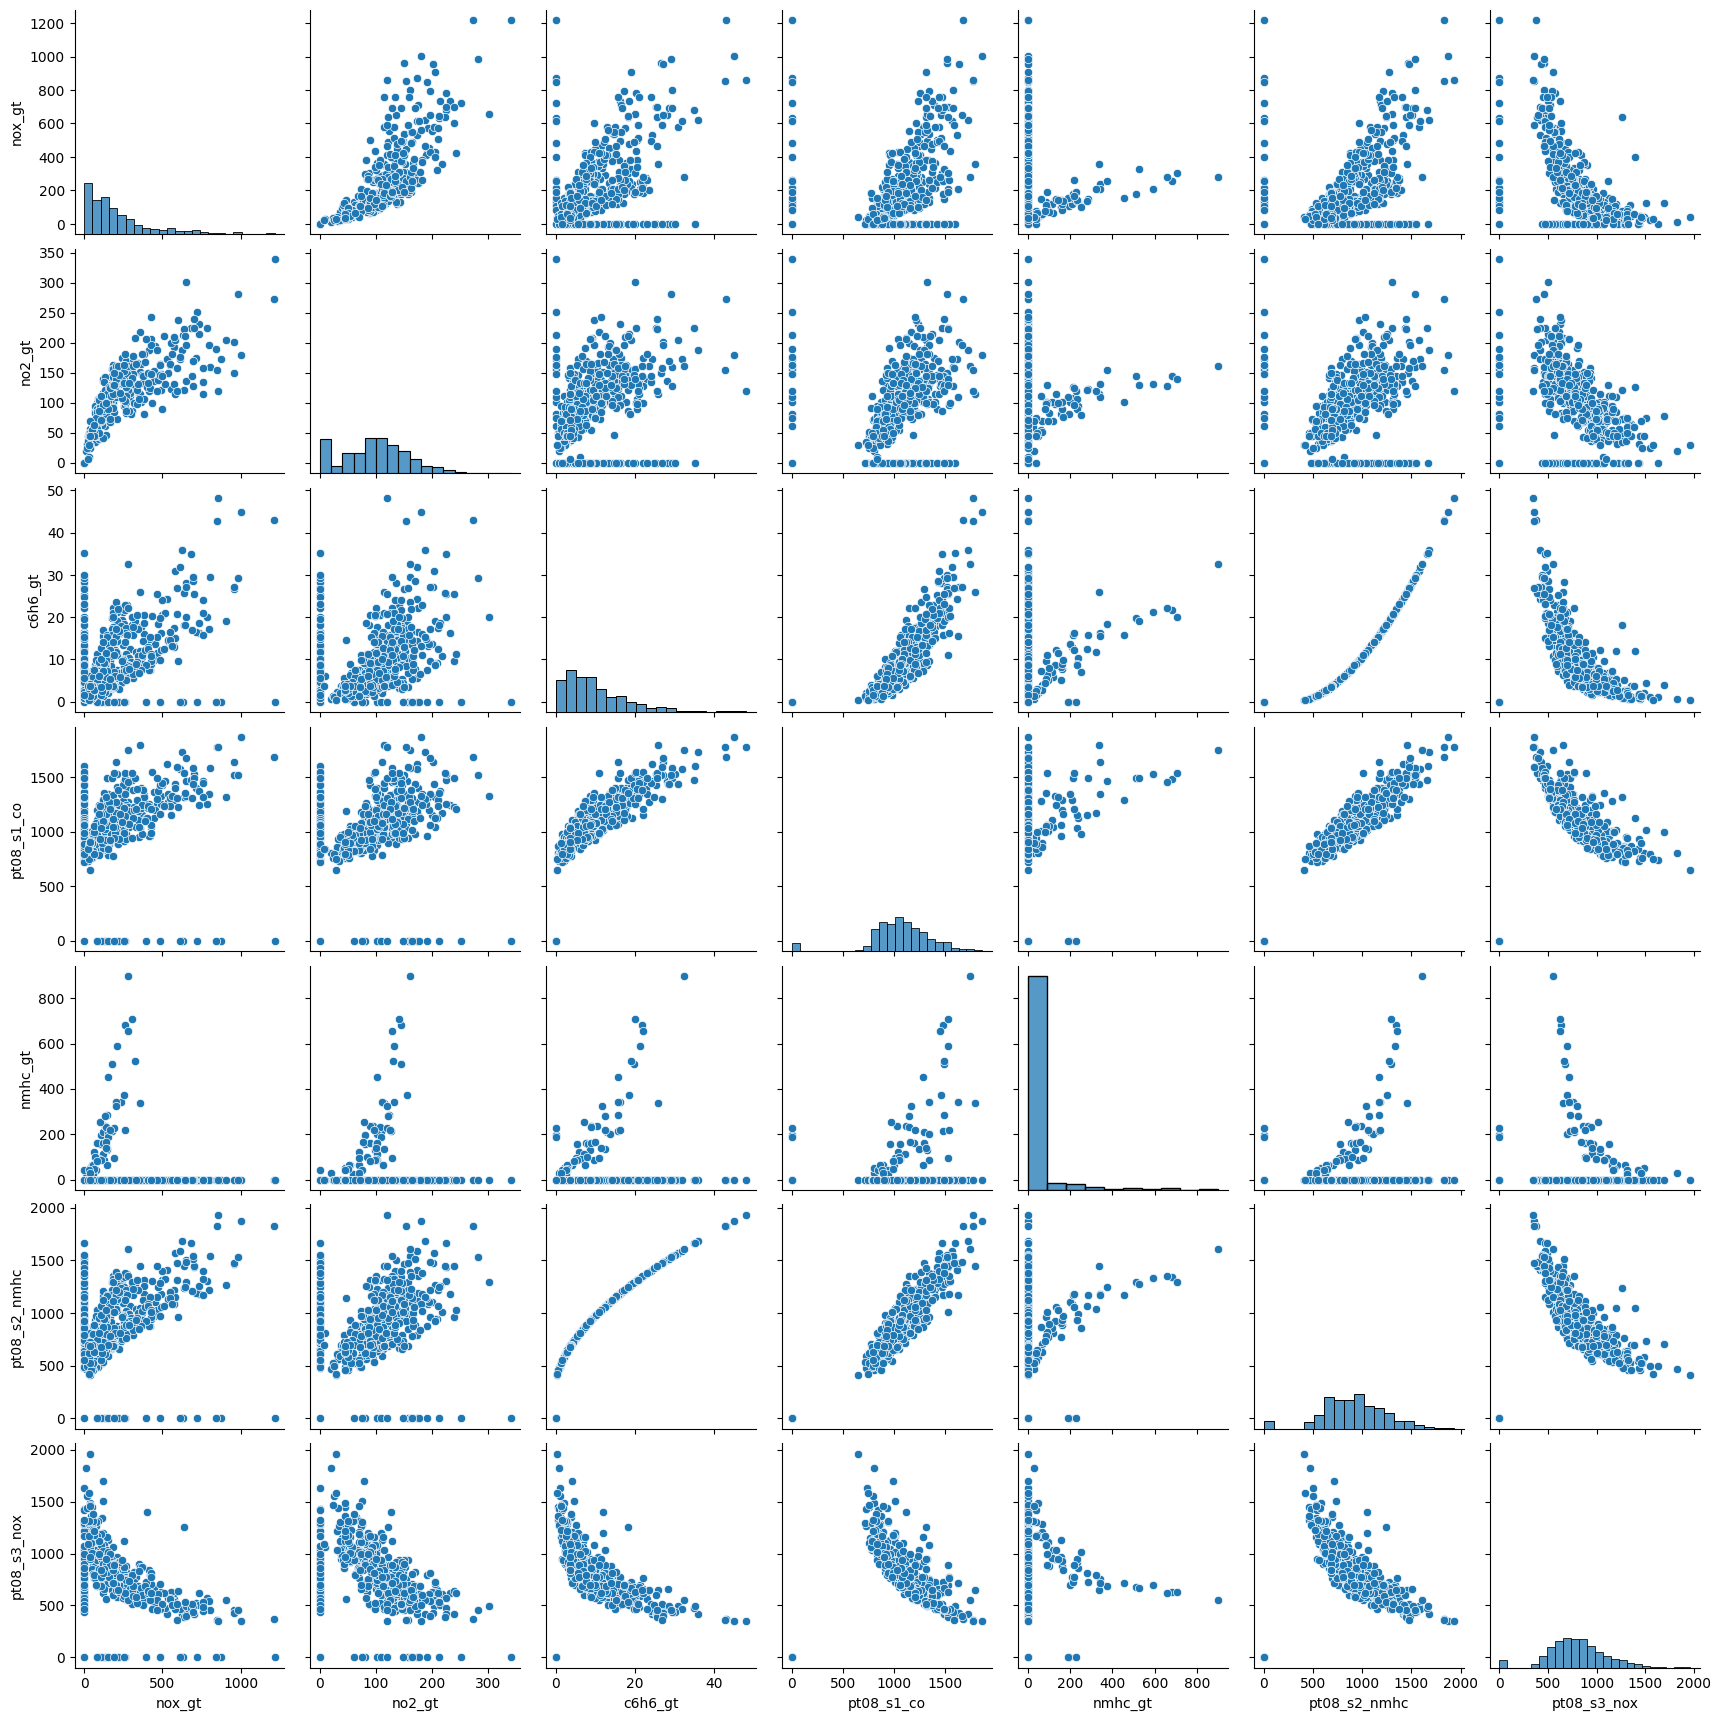

In [ ]:
import seaborn as sns

sns.pairplot(ac_df[cols].sample(500))
plt.show()

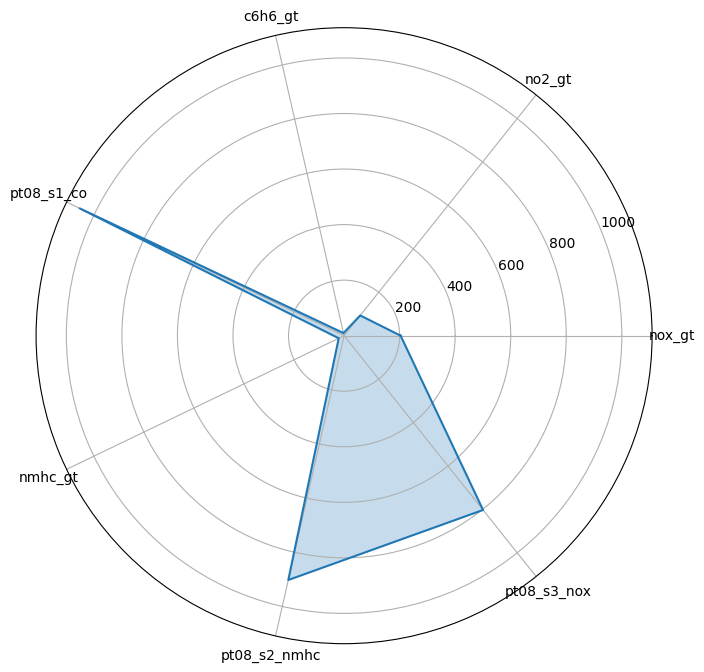

In [ ]:
import numpy as np

means = ac_df[cols].mean()

angles = np.linspace(0, 2*np.pi, len(cols), endpoint=False)
values = np.concatenate((means,[means.iloc[0]]))
angles = np.concatenate((angles,[angles[0]]))

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, polar=True)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cols)

plt.show()

Relation between pollutant and environment variables

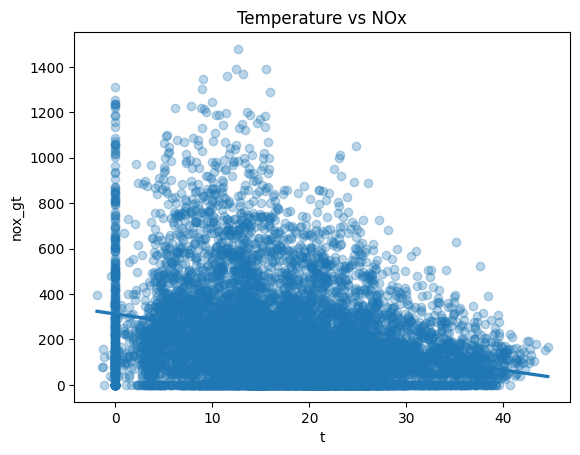

In [ ]:
sns.regplot(
    data=ac_df,
    x='t',
    y='nox_gt',
    scatter_kws={'alpha':0.3}
)

plt.title('Temperature vs NOx')
plt.show()

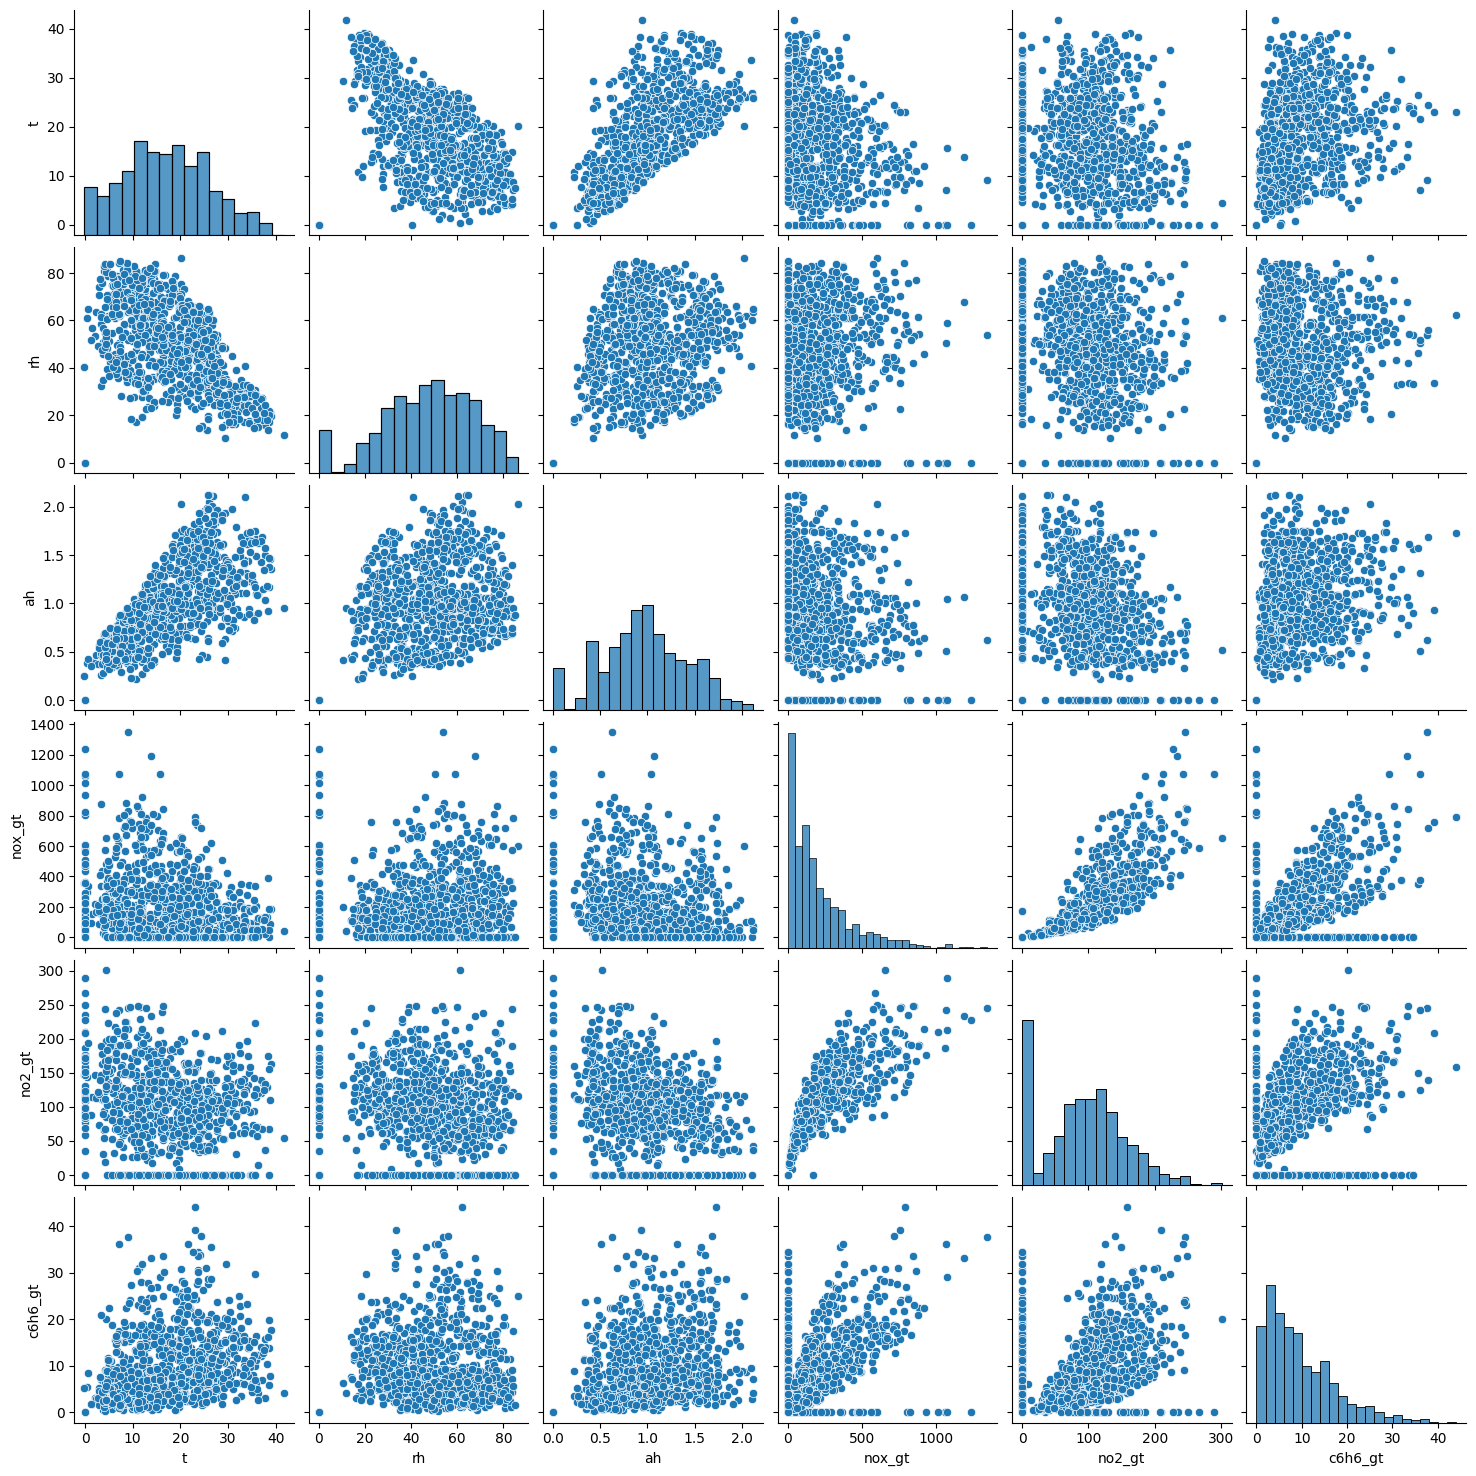

In [ ]:
cols = [
    't',
    'rh',
    'ah',
    'nox_gt',
    'no2_gt',
    'c6h6_gt'
]

sns.pairplot(ac_df[cols].dropna().sample(1000))
plt.show()

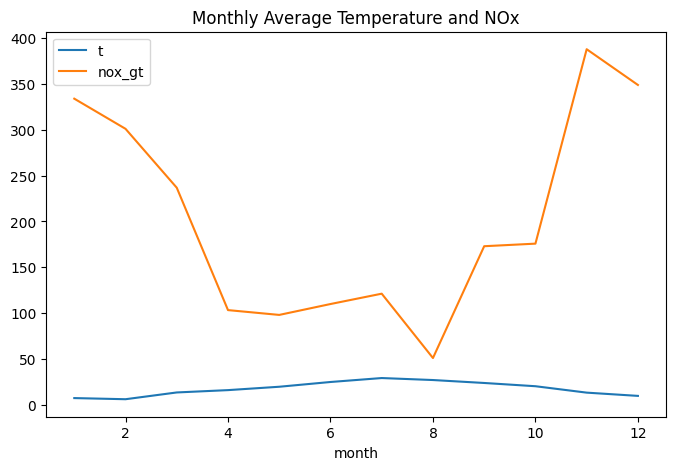

In [ ]:
ac_df['month'] = ac_df['date'].dt.month

monthly = ac_df.groupby('month')[['t','nox_gt']].mean()

monthly.plot(figsize=(8,5))
plt.title('Monthly Average Temperature and NOx')
plt.show()


Splitting data and scaling for model preparation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features
X = ac_df[
    ['co_gt', 'nmhc_gt', 'c6h6_gt',
     'pt08_s1_co', 'pt08_s2_nmhc',
     'pt08_s3_nox', 't', 'rh', 'ah']
]

# Target
y = ac_df['nox_gt']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(7485, 9)
(1872, 9)


XGBoost Model and Predictions

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("RMSE:", mean_squared_error(y_test,pred_xgb)**0.5)
print("MAE:", mean_absolute_error(y_test,pred_xgb))

y_pred = xgb.predict(X_test)

print(y_pred[:10])

RMSE: 70.220123339369
MAE: 45.19843568916505
[ 62.489628  23.50949  184.97559  492.00903  206.94707   19.823502
 177.65247  115.55944  144.99394   49.47409 ]


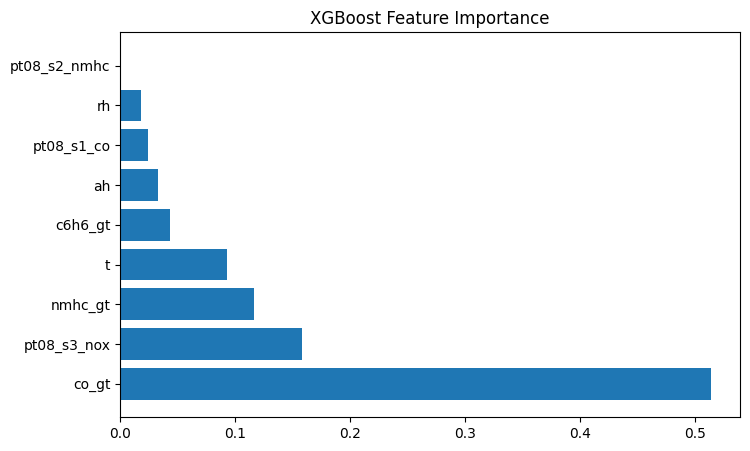

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

imp = imp.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(8,5))
plt.barh(
    imp["Feature"],
    imp["Importance"]
)
plt.title("XGBoost Feature Importance")
plt.show()


LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
import numpy as np

# Reshape input data for LSTM: (samples, timesteps, features)
# Here, each sample is considered as one timestep
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

lstm = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]) # (timesteps, features)
    ),

    Dropout(0.2),

    LSTM(32),

    Dense(16,activation='relu'),

    Dense(1)

])

lstm.compile(
    optimizer='adam',
    loss='mse'
)

history = lstm.fit(
    X_train_reshaped, # Use the reshaped training data
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 84034.8281 - val_loss: 78554.7812
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 65510.5508 - val_loss: 57849.2227
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 47916.4180 - val_loss: 41855.4688
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 35077.8516 - val_loss: 31228.5742
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 26294.3633 - val_loss: 23997.3516
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 20561.4043 - val_loss: 19027.5762
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 16702.6348 - val_loss: 15712.8242
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 14182.6924 - val_loss: 13482.2139
Epoch 9/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 12424.7041 - val_loss: 12022.9990
Epoch 10/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 11114.0781 - val_loss: 10960.1426
Epoch 11/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - los

In [ ]:
pred_lstm = lstm.predict(X_test_reshaped)
print(pred_lstm[:10])

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
[[ 83.376564]
 [ 15.53154 ]
 [195.82655 ]
 [461.22372 ]
 [211.40094 ]
 [ 25.504465]
 [189.70946 ]
 [145.23027 ]
 [140.22804 ]
 [ 61.81956 ]]


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_lstm.flatten()
    )
)

mae = mean_absolute_error(
    y_test,
    pred_lstm.flatten()
)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 80.24952896486408
MAE: 51.32094766161381


GRU Model Training and Evaluation

In [ ]:
from tensorflow.keras.layers import GRU

gru = Sequential([

    GRU(
        64,
        return_sequences=True,
        input_shape=(
            X_train_reshaped.shape[1],
            X_train_reshaped.shape[2]
        )
    ),

    Dropout(0.2),

    GRU(32),

    Dense(16,activation='relu'),

    Dense(1)

])

gru.compile(
    optimizer='adam',
    loss='mse'
)

gru.fit(
    X_train_reshaped,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 83414.5078 - val_loss: 78534.2188
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 68262.1641 - val_loss: 62644.9180
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 53500.2812 - val_loss: 48456.5430
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 41064.9609 - val_loss: 37128.1953
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 31622.2734 - val_loss: 28926.0664
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 24816.6230 - val_loss: 23090.9141
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 20071.6699 - val_loss: 18955.7539
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 16704.2480 - val_loss: 16023.8340
Epoch 9/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 14285.1963 - val_loss: 13910.3887
Epoch 10/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 12568.6172 - val_loss: 12393.0879
Epoch 11/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - 

In [ ]:
gru_pred = gru.predict(X_test_reshaped)
print(gru_pred[:10])

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
[[ 75.31139 ]
 [  3.967558]
 [181.73311 ]
 [461.51324 ]
 [208.7153  ]
 [ 14.389869]
 [177.0338  ]
 [136.76198 ]
 [128.03143 ]
 [ 54.346107]]


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

pred = lstm.predict(X_test_reshaped)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred.flatten()
    )
)

mae = mean_absolute_error(
    y_test,
    pred.flatten()
)

print(rmse)
print(mae)

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
80.24952896486408
51.32094766161381


Baseline model

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error

baseline_pred = np.full(
    len(y_test),
    y_train.mean()
)

mae_baseline = mean_absolute_error(
    y_test,
    baseline_pred
)

print(mae_baseline)
print(baseline_pred[:10])

156.61523059652066
[203.6942151 203.6942151 203.6942151 203.6942151 203.6942151 203.6942151
 203.6942151 203.6942151 203.6942151 203.6942151]
